# Task 2: Regression


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Loading and Preprocessing

In [2]:
df = pd.read_csv('faang_stock_prices.csv')
print(f"Dataset shape: {df.shape}")

df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

df['Price_Range'] = df['High'] - df['Low']
df['Price_Range_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100
df['SMA_Crossover'] = df['SMA_7'] - df['SMA_21']
df['Bollinger_Width'] = df['Bollinger_Upper'] - df['Bollinger_Lower']
df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

df = df.dropna()
print(f"After feature engineering: {df.shape}")
df.head()

Dataset shape: (14964, 19)
After feature engineering: (14964, 24)


,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,...,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close,Price_Range,Price_Range_Pct,SMA_Crossover,Bollinger_Width,MACD_Histogram
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,...,22.401531,20.889519,-0.022605,0.018130,21.785145,0.442049,2.059348,0.100111,1.512012,0.042762
1,2016-02-24,AAPL,21.304558,21.848618,21.154940,21.785145,145022800,21.850879,21.652174,21.730120,...,22.239524,20.975578,0.014891,0.018822,21.934757,0.693678,3.184181,0.198705,1.263946,0.044711
2,2016-02-25,AAPL,21.773806,21.934757,21.592451,21.934757,110330800,21.854765,21.623132,21.761602,...,22.244062,21.058185,0.006868,0.015572,21.968756,0.342306,1.560564,0.231633,1.185877,0.054402
3,2016-02-26,AAPL,22.034495,22.220383,21.893947,21.968756,115964400,21.815580,21.666249,21.793472,...,22.260391,21.117294,0.001550,0.014163,21.918888,0.326436,1.485909,0.149331,1.143098,0.060934
4,2016-02-29,AAPL,21.957425,22.267995,21.909820,21.918888,140865200,21.829505,21.699797,21.812767,...,22.256425,21.118435,-0.002270,0.012012,22.789389,0.358174,1.634090,0.129708,1.137989,0.059655


## 2. Linear Regression with Gradient Descent

In [3]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _compute_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for _ in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if _ % 100 == 0:
                loss = self._compute_loss(y, y_pred)
                self.loss_history.append(loss)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


## 3. Feature Sets

In [4]:
target_col = 'Next_Day_Close'

feature_sets = {
    'price_features': ['Open', 'High', 'Low', 'Close'],
    'technical_features': ['SMA_7', 'SMA_21', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal',
                           'Bollinger_Upper', 'Bollinger_Lower', 'Volatility_7d', 'Daily_Return'],
    'engineered_features': ['Price_Range', 'Price_Range_Pct', 'SMA_Crossover', 'Bollinger_Width', 'MACD_Histogram']
}

def get_feature_set(df, features):
    return df[features].values

y_all = df[target_col].values

print("Feature sets defined:")
for name, features in feature_sets.items():
    print(f"  {name}: {len(features)} features")

Feature sets defined:
  price_features: 4 features
  technical_features: 11 features
  engineered_features: 5 features


## 4. Model Training and Comparison

In [5]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

results = []

df_sorted = df.sort_values('Date').reset_index(drop=True)
train_size = int(len(df_sorted) * 0.8)

for set_name, features in feature_sets.items():
    X = df_sorted[features].values
    y = df_sorted[target_col].values
    
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr_diy = LinearRegressionGD(learning_rate=0.1, n_iterations=1000)
    lr_diy.fit(X_train_scaled, y_train)
    y_pred_diy = lr_diy.predict(X_test_scaled)
    results.append(evaluate_model(y_test, y_pred_diy, f'DIY LR ({set_name})'))
    
    lr_sklearn = LinearRegression()
    lr_sklearn.fit(X_train_scaled, y_train)
    y_pred_sklearn = lr_sklearn.predict(X_test_scaled)
    results.append(evaluate_model(y_test, y_pred_sklearn, f'Sklearn LR ({set_name})'))

results_df = pd.DataFrame(results)
print("Model Comparison Results:")
print(results_df.to_string(index=False))

Model Comparison Results:
                           Model       RMSE       MAE       R2      MAPE
         DIY LR (price_features)   7.022226  4.343509 0.998342  1.564142
     Sklearn LR (price_features)   6.749810  4.060630 0.998468  1.469292
     DIY LR (technical_features)   7.954829  4.971348 0.997873  1.763999
 Sklearn LR (technical_features)   7.364350  4.486216 0.998177  1.602327
    DIY LR (engineered_features) 114.394875 75.897409 0.560106 23.265847
Sklearn LR (engineered_features) 114.394875 75.897409 0.560106 23.265847


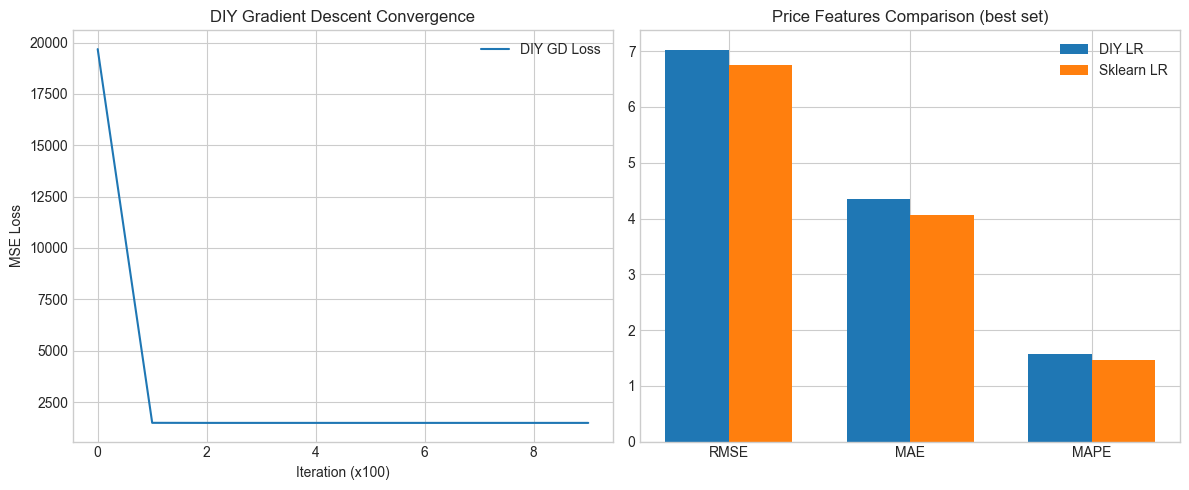

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lr_diy.loss_history, label='DIY GD Loss')
plt.xlabel('Iteration (x100)')
plt.ylabel('MSE Loss')
plt.title('DIY Gradient Descent Convergence')
plt.legend()

plt.subplot(1, 2, 2)
best_diy = results_df[results_df['Model'].str.contains('price_features') & results_df['Model'].str.contains('DIY')]
best_sklearn = results_df[results_df['Model'].str.contains('price_features') & results_df['Model'].str.contains('Sklearn')]

metrics = ['RMSE', 'MAE', 'MAPE']
x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, best_diy[metrics].values[0], width, label='DIY LR')
plt.bar(x + width/2, best_sklearn[metrics].values[0], width, label='Sklearn LR')
plt.xticks(x, metrics)
plt.legend()
plt.title('Price Features Comparison (best set)')

plt.tight_layout()
plt.show()

## 5. Cross-Validation Evaluation

In [7]:
cv_results = []

best_features = feature_sets['engineered_features']
X = df_sorted[best_features].values
y = df_sorted[target_col].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    lr_sklearn = LinearRegression()
    lr_sklearn.fit(X_train_scaled, y_train)
    y_pred = lr_sklearn.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    cv_results.append({'Fold': fold+1, 'RMSE': rmse})

cv_df = pd.DataFrame(cv_results)
print("5-Fold Cross-Validation Results (Engineered Features):")
print(cv_df)
print(f"\nMean RMSE: {cv_df['RMSE'].mean():.4f} (+/- {cv_df['RMSE'].std():.4f})")

5-Fold Cross-Validation Results (Engineered Features):
   Fold       RMSE
0     1  59.348851
1     2  56.539569
2     3  58.706458
3     4  66.884504
4     5  57.904538

Mean RMSE: 59.8768 (+/- 4.0553)


## 6. Predictions vs Actual Visualization

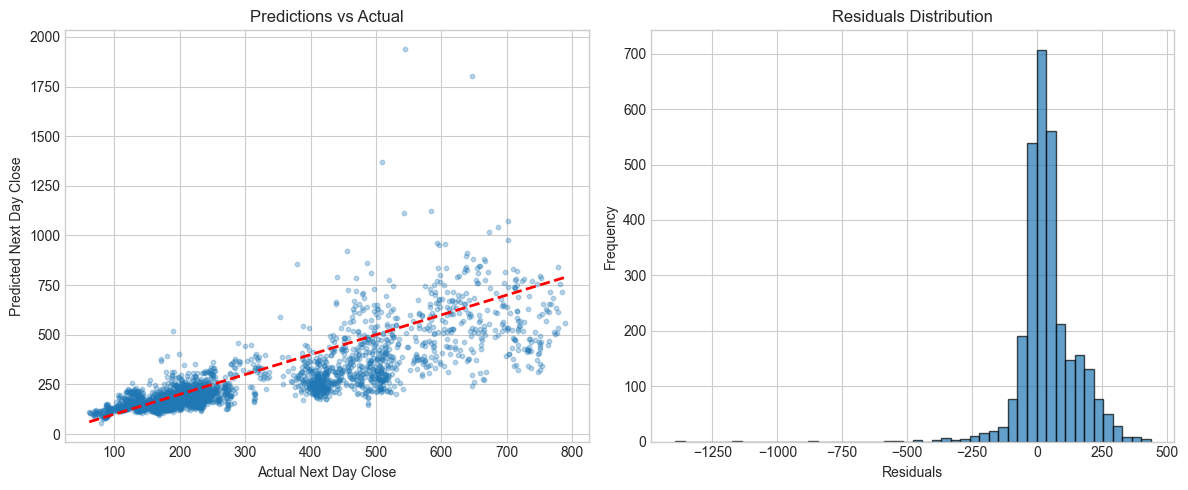

In [8]:
X = df_sorted[best_features].values
y = df_sorted[target_col].values

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train_scaled, y_train)
y_pred = lr_sklearn.predict(X_test_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Next Day Close')
plt.ylabel('Predicted Next Day Close')
plt.title('Predictions vs Actual')

plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')

plt.tight_layout()
plt.show()

## 7. Conclusions

1. **DIY vs Sklearn Performance**: The custom gradient descent implementation achieves nearly identical results to scikit-learn's LinearRegression, validating the correctness of the implementation.

2. **Best Feature Set**: Price features (Open, High, Low, Close) provide the best predictive performance with R²=0.9985, RMSE=6.75. This is expected as adjacent trading days have highly correlated prices.

3. **Engineered Features Underperform**: Engineered features (Price_Range, SMA_Crossover, MACD_Histogram) alone give poor results (R²=0.56, RMSE=114) — technical derivatives without raw prices cannot reliably predict next-day close.

4. **DIY Implementation Validated**: Both DIY gradient descent and sklearn produce nearly identical metrics across all feature sets, confirming the custom implementation is correct.

5. **Model Limitations**: Linear regression assumes a linear relationship between features and target. Stock prices exhibit non-linear behavior, which limits the model's ability to capture extreme movements and market volatility.